In [8]:
from owlready2 import *
import matplotlib.pyplot as plt
from raresim.utils.paths import ONTOLOGY_DIR

# ORDO Overview


Which datasets are they using?

Loading ORDO ontology...
Ontology loaded.
Total classes (terms): 16036
Total individuals: 0
Object properties: 13
Annotation properties: 23
Max depth: 13
Average depth: 4.06
Average number of children per term: 1.60
Average number of ancestors per term: 5.38
Average labels per term: 1.00
Average synonyms per term: 0.00


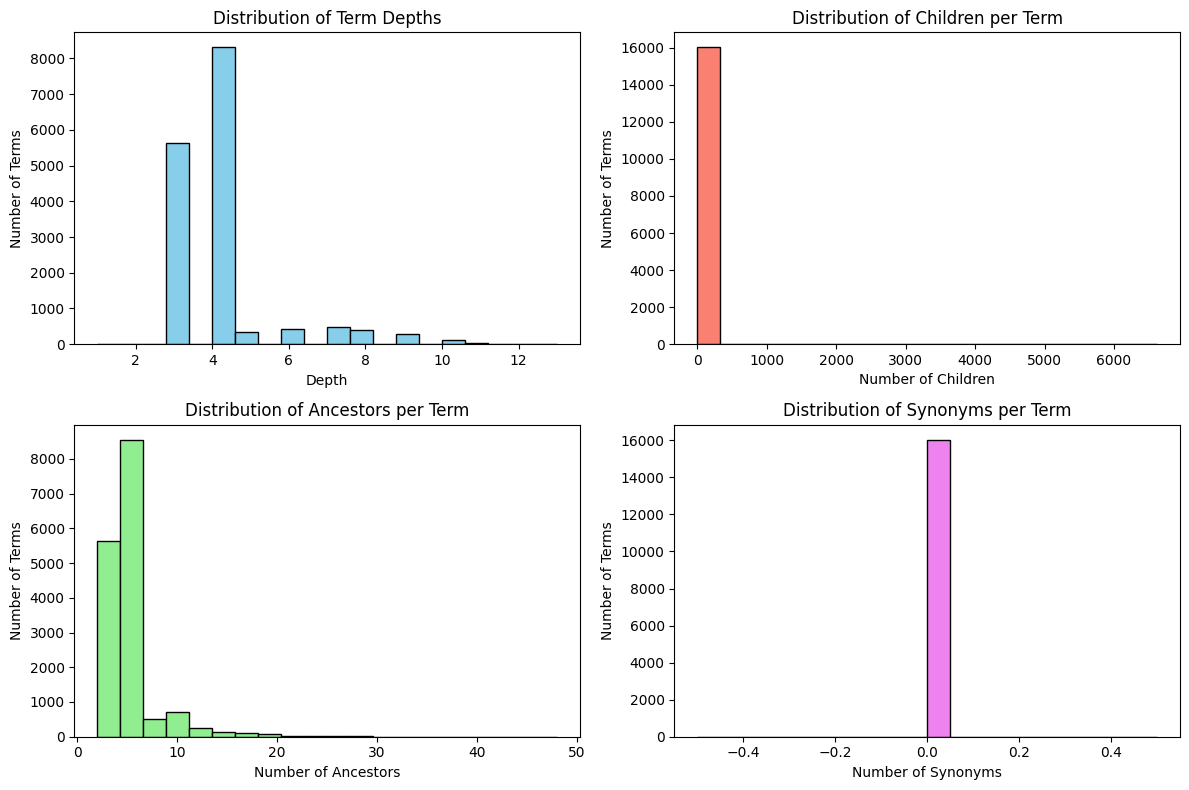

In [9]:
# Load ORDO ontology (ORDO OWL file URL)
print("Loading ORDO ontology...")
ordo = get_ontology(f"{ONTOLOGY_DIR}/ordo.owl").load()
print("Ontology loaded.")

# --- 1. Basic Counts ---
classes = list(ordo.classes())
individuals = list(ordo.individuals())
object_props = list(ordo.object_properties())
annotation_props = list(ordo.annotation_properties())

print(f"Total classes (terms): {len(classes)}")
print(f"Total individuals: {len(individuals)}")
print(f"Object properties: {len(object_props)}")
print(f"Annotation properties: {len(annotation_props)}")

# --- 2. Hierarchy Statistics ---

def get_depth(cls):
    if not cls.is_a:
        return 0
    parent_depths = [get_depth(parent) for parent in cls.is_a if isinstance(parent, ThingClass)]
    return 1 + max(parent_depths) if parent_depths else 1

depths = [get_depth(c) for c in classes]
max_depth = max(depths)
avg_depth = sum(depths)/len(depths)
print(f"Max depth: {max_depth}")
print(f"Average depth: {avg_depth:.2f}")

# Children per term
children_counts = [len(list(c.subclasses())) for c in classes]
avg_children = sum(children_counts)/len(children_counts)
print(f"Average number of children per term: {avg_children:.2f}")

# Ancestors per term
ancestor_counts = [len(list(c.ancestors())) for c in classes]
avg_ancestors = sum(ancestor_counts)/len(ancestor_counts)
print(f"Average number of ancestors per term: {avg_ancestors:.2f}")

# --- 3. Term Annotations ---
label_counts = [len(c.label) if c.label else 0 for c in classes]
# ORDO often has synonyms in hasExactSynonym
synonym_counts = [len(c.hasExactSynonym) if hasattr(c, "hasExactSynonym") else 0 for c in classes]

print(f"Average labels per term: {sum(label_counts)/len(classes):.2f}")
print(f"Average synonyms per term: {sum(synonym_counts)/len(classes):.2f}")

# --- 4. Visualizations ---
plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
plt.hist(depths, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Term Depths")
plt.xlabel("Depth")
plt.ylabel("Number of Terms")

plt.subplot(2,2,2)
plt.hist(children_counts, bins=20, color='salmon', edgecolor='black')
plt.title("Distribution of Children per Term")
plt.xlabel("Number of Children")
plt.ylabel("Number of Terms")

plt.subplot(2,2,3)
plt.hist(ancestor_counts, bins=20, color='lightgreen', edgecolor='black')
plt.title("Distribution of Ancestors per Term")
plt.xlabel("Number of Ancestors")
plt.ylabel("Number of Terms")

plt.subplot(2,2,4)
plt.hist(synonym_counts, bins=20, color='violet', edgecolor='black')
plt.title("Distribution of Synonyms per Term")
plt.xlabel("Number of Synonyms")
plt.ylabel("Number of Terms")

plt.tight_layout()
plt.show()

# --- 5. Optional: Top-level branch example ---
# Example: ORDO top-level class "Rare disease"
rare_disease_root = ordo.search_one(label="Rare disease")
if rare_disease_root:
    rd_subclasses = list(rare_disease_root.subclasses())
    print(f"Number of terms under 'Rare disease': {len(rd_subclasses)}")

In [10]:
def find_ordo_term(identifier, ontology):
    """
    Robust search for an ORDO term by:
    - label
    - class name
    - ORPHA id inside cross references
    """
    
    # 1. Try direct label search
    term = ontology.search_one(label=identifier)
    if term:
        return term

    # 2. Try name match
    for cls in ontology.classes():
        if cls.name.lower() == identifier.lower():
            return cls

    # 3. Search inside cross references
    for cls in ontology.classes():
        for prop in cls.get_properties():
            for value in prop[cls]:
                if isinstance(value, str) and identifier in value:
                    return cls

    return None


def print_ordo_term(identifier, ontology):
    
    term = find_ordo_term(identifier, ontology)

    if not term:
        print(f"Term '{identifier}' not found.")
        return

    print("\n==============================")
    print("ORDO TERM OVERVIEW")
    print("==============================")

    print(f"Class name: {term.name}")

    if term.label:
        print(f"Label: {term.label[0]}")

    # Definition
    if hasattr(term, "definition") and term.definition:
        print(f"\nDefinition:")
        for d in term.definition:
            print(f"  - {d}")

    # Synonyms
    if hasattr(term, "hasExactSynonym") and term.hasExactSynonym:
        print("\nSynonyms:")
        for s in term.hasExactSynonym:
            print(f"  - {s}")

    # Parents
    parents = [p for p in term.is_a if isinstance(p, ThingClass)]
    print("\nParents:")
    for p in parents:
        print(f"  - {p.name}")

    # Children
    print("\nChildren:")
    children = list(term.subclasses())
    for c in children[:10]:
        print(f"  - {c.name}")
    if len(children) > 10:
        print(f"  ... ({len(children)} total)")

    # Ancestors
    print(f"\nAncestor count: {len(list(term.ancestors()))}")

    # External references
    print("\nExternal database references:")
    found = False
    for prop in term.get_class_properties():
        values = prop[term]
        for val in values:
            if isinstance(val, str) and ":" in val:
                print(f"  - {prop.name}: {val}")
                found = True

    if not found:
        print("  None found")

    print("==============================\n")

In [11]:
print_ordo_term("Orphanet_84", ordo)  # By ORDO ID
print_ordo_term("Cystic fibrosis", ordo)  # By label


ORDO TERM OVERVIEW
Class name: Orphanet_84
Label: Fanconi anemia

Definition:
  - A rare genetic multisystem disorder characterized by progressive pancytopenia with bone marrow failure, variable congenital malformations and predisposition to develop hematological or solid tumors.

Parents:
  - Orphanet_377789
  - Orphanet_557493

Children:

Ancestor count: 5

External database references:
  - notation: ORPHA:84
  - Orphanet_C022: China AND has_point_prevalence_average_value : 0.111 AND has_point_prevalence_range : 1-9 / 1 000 000
  - Orphanet_C022: Europe AND has_birth_prevalence_average_value : 0.62 AND has_birth_prevalence_range : 1-9 / 1 000 000
  - Orphanet_C022: Europe AND has_point_prevalence_average_value : 0.3 AND has_point_prevalence_range : 1-9 / 1 000 000
  - Orphanet_C022: Israel AND has_birth_prevalence_average_value : 2.2 AND has_birth_prevalence_range : 1-9 / 100 000
  - Orphanet_C022: Specific population AND has_point_prevalence_average_value : 2.5 AND has_point_preval